# Counting - Images

## Setup

Set up `sys.path` to work while within a subfolder.

In [1]:
import sys
sys.path.append("../..")

Enable this if working within VSCode.

In [2]:
import os

if not os.environ.get("NOTEBOOK_PATH"):
    os.environ["NOTEBOOK_PATH"] = "notebooks/part-1/counting.ipynb"

Manim-related imports.

In [3]:
from manim import *
from manim_utils import *

Set up the image generation cell magic.

In [4]:
%load_ext magics.generate_image

Loaded extension.


## Scenes

### The Counting of Five Items
The dialogue at the start of the chapter.

Common constants for the scenes.

In [82]:
ITEM_CLASSES = [Circle, Star, Triangle, Square, RegularPolygon]
ITEM_COLOURS = [RED, BLUE, GREEN, ORANGE, GRAY]
ITEM_RADIUS = 0.75
ITEM_SPACING = 2

LABEL_SHIFT = 1.25  # Downwards

Helper functions to set up items and labels.

In [83]:
def create_items() -> VGroup:
    items = []
    for i in range(5):
        cls = ITEM_CLASSES[i]
        if cls == Circle:
            item = cls(radius=ITEM_RADIUS)
        elif cls == Square:
            item = cls(side_length=ITEM_RADIUS * 2)
        elif cls == Star:
            item = cls(outer_radius=ITEM_RADIUS)
        elif cls == Triangle or cls == RegularPolygon:
            if cls == Triangle:
                item = RegularPolygon(n=3)
            else:
                item = RegularPolygon(n=6)
            item = cls().scale(ITEM_RADIUS)
        else:
            raise ValueError(f"Unknown class {cls}")
        item.set_color(ITEM_COLOURS[i])
        item.set_fill(ITEM_COLOURS[i], opacity=0.25)
        item.move_to((i-2) * ITEM_SPACING * RIGHT)
        items.append(item)

    return VGroup(*items)

In [84]:
def create_labels(items: VGroup, labels: list[tuple[int, ...]]) -> VGroup:
    assert len(labels) == 5

    label_objects = []
    for i, item in enumerate(items):
        the_labels = labels[i]
        if len(the_labels) == 0:
            continue
            
        label = Text(f"{', '.join([str(x) for x in the_labels])}", color=BLACK)
        label.move_to(item)
        label.shift(LABEL_SHIFT * DOWN)
        label_objects.append(label)

    return VGroup(*label_objects)

Non-injective, non-surjective counting.

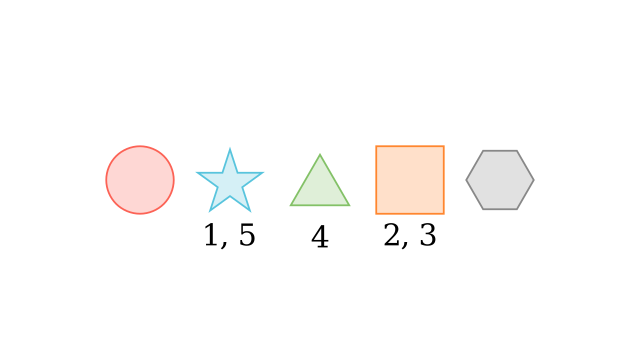

In [87]:
%%generate_image five-count_noninj-nonsurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (),
            (1,5),
            (4,),
            (2,3),
            ()
        ]
        labels = create_labels(items, labels)
        self.add(labels)

Injective, non-surjective counting.

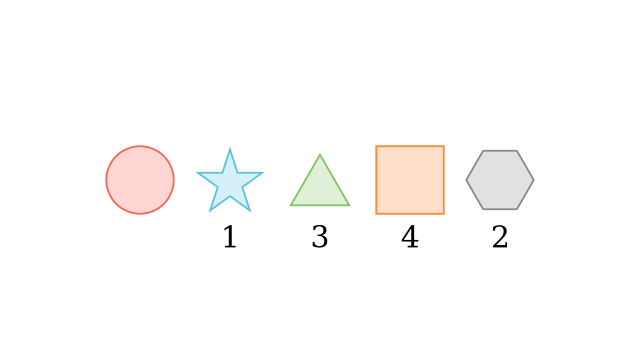

In [86]:
%%generate_image five-count_yesinj-nonsurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (),
            (1,),
            (3,),
            (4,),
            (2,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)

Non-injective, surjective counting.

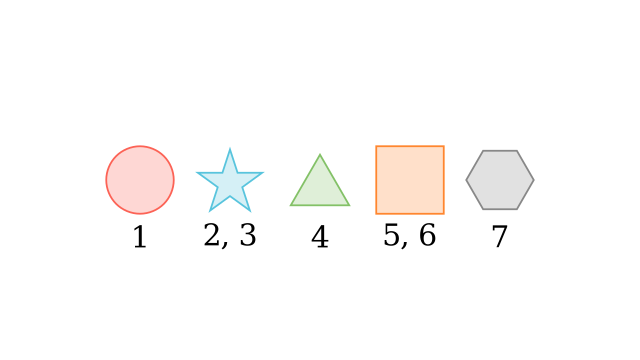

In [89]:
%%generate_image five-count_noninj-yessurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,),
            (2,3),
            (4,),
            (5,6),
            (7,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)

Injective, surjective counting.

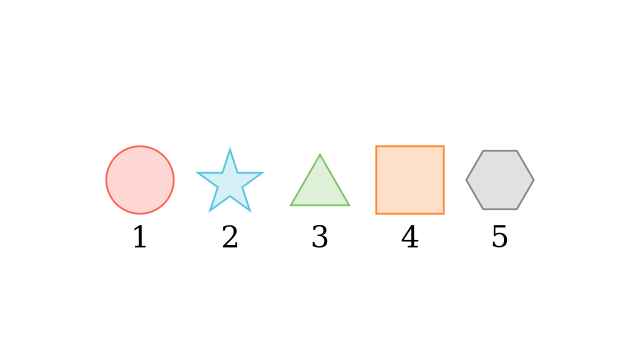

In [90]:
%%generate_image five-count_yesinj-yessurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,),
            (2,),
            (3,),
            (4,),
            (5,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)

Disregarding stars...

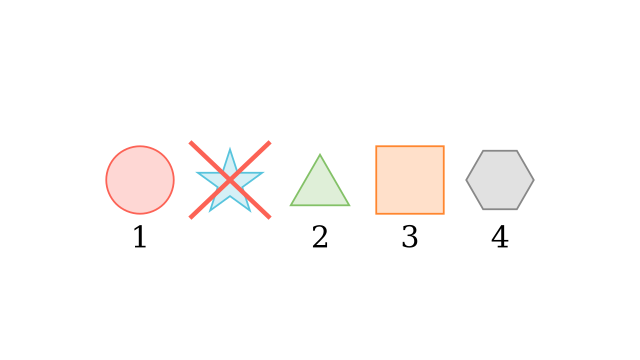

In [92]:
%%generate_image five-count_no-star CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,),
            (),
            (2,),
            (3,),
            (4,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)
        
        # Cross out the star
        cross = Cross(items[1], stroke_width=10.0, scale_factor=1.25)  # Which is the star
        self.add(cross)
